In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import imblearn
import itertools
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn import metrics as metrics
import warnings
warnings.filterwarnings('ignore')

In [2]:
test = pd.read_csv("UNSW_NB15_testing-set.csv")
test = test.iloc[:,:-1] 

In [3]:
train = pd.read_csv("UNSW_NB15_training-set.csv")
train = train.iloc[:,:-1] 

In [4]:
def bar_graph(feature):
    train[feature].value_counts().plot(kind="bar")


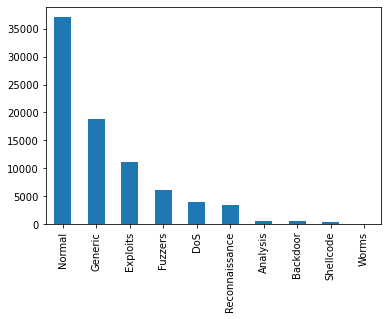

In [5]:
bar_graph('attack_cat')

In [6]:
y = train["attack_cat"].values
from collections import Counter
Counter(y)

Counter({'Normal': 37000,
         'Reconnaissance': 3496,
         'Backdoor': 583,
         'DoS': 4089,
         'Exploits': 11132,
         'Analysis': 677,
         'Fuzzers': 6062,
         'Worms': 44,
         'Shellcode': 378,
         'Generic': 18871})

In [7]:
y1 = test["attack_cat"].values
from collections import Counter
Counter(y1)

Counter({'Normal': 56000,
         'Backdoor': 1746,
         'Analysis': 2000,
         'Fuzzers': 18184,
         'Shellcode': 1133,
         'Reconnaissance': 10491,
         'Exploits': 33393,
         'DoS': 12264,
         'Worms': 130,
         'Generic': 40000})

In [8]:
from sklearn.preprocessing import LabelEncoder
encodings = dict()
for c in train.columns:
    
    if train[c].dtype == "object":
        encodings[c] = LabelEncoder()
        encodings[c]
        train[c] = encodings[c].fit_transform(train[c])

In [9]:
y = train.pop("attack_cat").values
X = train.values

In [10]:
train.dtypes

id                     int64
dur                  float64
proto                  int32
service                int32
state                  int32
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [11]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

In [12]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=10)

_ = rfe.fit(X, y)

In [13]:
print(X.shape)
X_train_rfe = X[:, rfe.support_]
print(X_train_rfe.shape)

(82332, 43)
(82332, 10)


In [14]:
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(rfe.transform(X), y, test_size=0.2, random_state=42)

In [15]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_rfe, y_train_rfe)

KNeighborsClassifier()

In [16]:
y_pred_rfe = neigh.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 7460, 5: 3680, 3: 2464, 4: 1196, 2: 784, 7: 662, 0: 145, 1: 40, 8: 36})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [17]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[  12    3   20   71   23    0    2    0    0    0]
 [   4    1    8   73   26    0    0    5    0    0]
 [   9   11  313  380   42    5    3   19    4    0]
 [  76   12  327 1598  150   18   22   64    8    0]
 [  44    8   45  147  844   28   67   23    6    0]
 [   0    1   14   60   20 3609    5   13    1    0]
 [   0    0    1    5   44   12 7352    2    2    0]
 [   0    4   49  112   39    6    4  508    1    0]
 [   0    0    7   11    8    2    5   28   14    0]
 [   0    0    0    7    0    0    0    0    0    0]]
Accuracy Score : 0.865427825347665
Report : 
              precision    recall  f1-score   support

           0       0.08      0.09      0.09       131
           1       0.03      0.01      0.01       117
           2       0.40      0.40      0.40       786
           3       0.65      0.70      0.67      2275
           4       0.71      0.70      0.70      1212
           5       0.98      0.97      0.98      3723
           6       0.99   

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8599559705458134
Report : 
              precision    recall  f1-score   support

           0       0.10      0.10      0.10       546
           1       0.01      0.00      0.00       466
           2       0.40      0.39      0.40      3303
           3       0.64      0.70      0.67      8857
           4       0.67      0.66      0.67      4850
           5       0.98      0.97      0.97     15148
           6       0.98      0.99      0.99     29582
           7       0.74      0.71      0.72      2773
           8       0.42      0.11      0.18       303
           9       0.00      0.00      0.00        37

    accuracy                           0.86     65865
   macro avg       0.49      0.46      0.47     65865
weighted avg       0.86      0.86      0.86     65865



In [19]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_rfe, y_train_rfe)

SVC(decision_function_shape='ovo', gamma='auto')

In [20]:
y_pred_rfe=clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 7356, 5: 3749, 3: 2215, 4: 1619, 2: 906, 7: 617, 8: 5})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [21]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[   0    0   31   28   57    0   12    3    0    0]
 [   0    0    4   36   68    1    5    3    0    0]
 [   0    0  397  247   87    6   22   26    1    0]
 [   0    0  354 1530  214   10  117   49    1    0]
 [   0    0   46  119  826   60  137   24    0    0]
 [   0    0    4   84   10 3582   21   22    0    0]
 [   0    0    4   58  277   81 6980   18    0    0]
 [   0    0   60   90   69    8   49  447    0    0]
 [   0    0    6   18   11    1   11   25    3    0]
 [   0    0    0    5    0    0    2    0    0    0]]
Accuracy Score : 0.8359142527479201
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.44      0.51      0.47       786
           3       0.69      0.67      0.68      2275
           4       0.51      0.68      0.58      1212
           5       0.96      0.96      0.96      3723
           6       0.95  

In [22]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8329461777878995
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.44      0.48      0.46      3303
           3       0.68      0.68      0.68      8857
           4       0.50      0.66      0.57      4850
           5       0.95      0.96      0.96     15148
           6       0.95      0.94      0.94     29582
           7       0.69      0.63      0.66      2773
           8       0.40      0.01      0.01       303
           9       0.00      0.00      0.00        37

    accuracy                           0.83     65865
   macro avg       0.46      0.44      0.43     65865
weighted avg       0.83      0.83      0.83     65865



In [23]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_rfe, y_train_rfe)

In [24]:
y_pred_rfe = clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 8643, 5: 4412, 3: 1552, 7: 799, 2: 667, 4: 390, 0: 4})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [25]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Accuracy Score : 0.7305520131171434
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.43      0.37      0.40       786
           3       0.53      0.36      0.43      2275
           4       0.47      0.15      0.23      1212
           5       0.81      0.96      0.88      3723
           6       0.78      0.91      0.84      7418
           7       0.55      0.60      0.57       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.73     16467
   macro avg       0.36      0.34      0.33     16467
weighted avg       0.69      0.73      0.70     16467



In [26]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.73009944583618
Report : 
              precision    recall  f1-score   support

           0       0.18      0.01      0.01       546
           1       0.00      0.00      0.00       466
           2       0.43      0.34      0.38      3303
           3       0.52      0.36      0.43      8857
           4       0.42      0.14      0.21      4850
           5       0.81      0.96      0.88     15148
           6       0.78      0.91      0.84     29582
           7       0.52      0.62      0.57      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.73     65865
   macro avg       0.37      0.33      0.33     65865
weighted avg       0.68      0.73      0.70     65865



In [27]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_rfe, y_train_rfe)
clf

MLPClassifier(alpha=1)

In [28]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[   0    0   27    8    6   38   51    1    0    0]
 [   0    0    4   14    4   41   49    5    0    0]
 [   1    0  289  181    9  129  113   64    0    0]
 [   3    0  249  822   20  176  834  171    0    0]
 [   0    0   37  187  185  158  623   22    0    0]
 [   0    0    2   47    3 3567   80   24    0    0]
 [   0    0   14  203  152  279 6731   39    0    0]
 [   0    0   44   72    9   24  138  436    0    0]
 [   0    0    1   14    2    0   21   37    0    0]
 [   0    0    0    4    0    0    3    0    0    0]]
Accuracy Score : 0.7305520131171434
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.43      0.37      0.40       786
           3       0.53      0.36      0.43      2275
           4       0.47      0.15      0.23      1212
           5       0.81      0.96      0.88      3723
           6       0.78  

In [29]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8236999924087148
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.44      0.26      0.33      3303
           3       0.63      0.67      0.65      8857
           4       0.55      0.57      0.56      4850
           5       0.88      0.96      0.92     15148
           6       0.94      0.96      0.95     29582
           7       0.63      0.62      0.63      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.82     65865
   macro avg       0.41      0.41      0.40     65865
weighted avg       0.80      0.82      0.81     65865



In [30]:
#RandomForest
from sklearn.metrics import classification_report 
forest = RandomForestRegressor()
_ = forest.fit(X_train_rfe, y_train_rfe)
arr = forest.predict(X_train_rfe).astype(int)
print(classification_report(y_train_rfe, arr))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81       546
           1       0.57      0.83      0.68       466
           2       0.38      0.90      0.53      3303
           3       0.64      0.45      0.53      8857
           4       0.80      0.57      0.66      4850
           5       0.97      0.97      0.97     15148
           6       0.98      1.00      0.99     29582
           7       0.92      0.70      0.80      2773
           8       0.50      0.02      0.04       303
           9       0.00      0.00      0.00        37

    accuracy                           0.86     65865
   macro avg       0.66      0.62      0.60     65865
weighted avg       0.88      0.86      0.86     65865



In [31]:
arr = forest.predict(X_test_rfe).astype(int)
print(classification_report(y_test_rfe, arr))
print('Accuracy Score :',accuracy_score(y_test_rfe,arr))

              precision    recall  f1-score   support

           0       0.17      0.05      0.08       131
           1       0.16      0.30      0.21       117
           2       0.25      0.66      0.36       786
           3       0.49      0.32      0.39      2275
           4       0.74      0.51      0.60      1212
           5       0.95      0.97      0.96      3723
           6       0.99      1.00      0.99      7418
           7       0.95      0.68      0.79       723
           8       1.00      0.03      0.05        75
           9       0.00      0.00      0.00         7

    accuracy                           0.81     16467
   macro avg       0.57      0.45      0.44     16467
weighted avg       0.84      0.81      0.82     16467

Accuracy Score : 0.8133843444464687


In [32]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_rfe, y_train_rfe)
y_pred  =  classifier.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.10      0.79      0.17       546
           1       0.00      0.00      0.00       466
           2       0.00      0.00      0.00      3303
           3       0.53      0.08      0.14      8857
           4       0.24      0.15      0.19      4850
           5       0.94      0.84      0.89     15148
           6       0.79      0.55      0.65     29582
           7       0.07      0.01      0.02      2773
           8       0.02      0.97      0.03       303
           9       0.00      0.19      0.00        37

    accuracy                           0.47     65865
   macro avg       0.27      0.36      0.21     65865
weighted avg       0.66      0.47      0.53     65865



In [33]:
y_pred  =  classifier.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.09      0.74      0.16       131
           1       0.01      0.01      0.01       117
           2       0.00      0.00      0.00       786
           3       0.59      0.09      0.16      2275
           4       0.23      0.15      0.18      1212
           5       0.94      0.83      0.88      3723
           6       0.79      0.56      0.65      7418
           7       0.04      0.01      0.01       723
           8       0.02      0.96      0.03        75
           9       0.00      0.29      0.00         7

    accuracy                           0.47     16467
   macro avg       0.27      0.36      0.21     16467
weighted avg       0.67      0.47      0.53     16467

Accuracy Score : 0.4738568045181272


In [34]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_rfe, y_train_rfe)
y_pred = clf_entropy.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.00      0.00      0.00      3303
           3       0.48      0.51      0.49      8857
           4       0.00      0.00      0.00      4850
           5       1.00      0.96      0.98     15148
           6       0.70      0.99      0.82     29582
           7       0.00      0.00      0.00      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.74     65865
   macro avg       0.22      0.25      0.23     65865
weighted avg       0.61      0.74      0.66     65865



In [35]:
y_pred = clf_entropy.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.00      0.00      0.00       786
           3       0.49      0.50      0.49      2275
           4       0.00      0.00      0.00      1212
           5       1.00      0.96      0.98      3723
           6       0.70      1.00      0.82      7418
           7       0.00      0.00      0.00       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.73     16467
   macro avg       0.22      0.25      0.23     16467
weighted avg       0.61      0.73      0.66     16467

Accuracy Score : 0.7348029392117569


In [36]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=20)

_ = rfe.fit(X, y)

In [37]:
print(X.shape)
X_train_rfe = X[:, rfe.support_]
print(X_train_rfe.shape)

(82332, 43)
(82332, 20)


In [38]:
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(rfe.transform(X), y, test_size=0.2, random_state=42)

In [39]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_rfe, y_train_rfe)

KNeighborsClassifier()

In [40]:
y_pred_rfe = neigh.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 7601, 5: 3643, 3: 2391, 4: 1178, 2: 794, 7: 630, 0: 148, 1: 43, 8: 37, 9: 2})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [41]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[  10    2   21   74   23    0    1    0    0    0]
 [   5    0    7   75   24    1    3    2    0    0]
 [   9   12  307  378   35    8   15   16    6    0]
 [  79   15  337 1486  167   15   76   93    7    0]
 [  45    8   47  165  716    4  186   37    3    1]
 [   0    1   17   61   10 3610   15    8    0    1]
 [   0    0    3   11  140    3 7252    6    3    0]
 [   0    5   55  126   48    1   48  438    2    0]
 [   0    0    0   10   15    1    4   29   16    0]
 [   0    0    0    5    0    0    1    1    0    0]]
Accuracy Score : 0.8401651788425335
Report : 
              precision    recall  f1-score   support

           0       0.07      0.08      0.07       131
           1       0.00      0.00      0.00       117
           2       0.39      0.39      0.39       786
           3       0.62      0.65      0.64      2275
           4       0.61      0.59      0.60      1212
           5       0.99      0.97      0.98      3723
           6       0.95  

In [42]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8380323388749715
Report : 
              precision    recall  f1-score   support

           0       0.07      0.07      0.07       546
           1       0.00      0.00      0.00       466
           2       0.39      0.38      0.39      3303
           3       0.62      0.66      0.64      8857
           4       0.58      0.59      0.58      4850
           5       0.99      0.97      0.98     15148
           6       0.95      0.98      0.96     29582
           7       0.69      0.61      0.65      2773
           8       0.43      0.12      0.19       303
           9       0.00      0.00      0.00        37

    accuracy                           0.84     65865
   macro avg       0.47      0.44      0.45     65865
weighted avg       0.83      0.84      0.83     65865



In [43]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_rfe, y_train_rfe)

SVC(decision_function_shape='ovo', gamma='auto')

In [44]:
y_pred_rfe=clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 7560, 5: 3602, 3: 2213, 4: 1563, 2: 906, 7: 617, 8: 6})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [45]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[   0    0   30   36   54    0    6    5    0    0]
 [   0    0    5   42   62    0    5    3    0    0]
 [   0    0  398  240   85    2   21   39    1    0]
 [   0    0  353 1543  203    1  114   59    2    0]
 [   0    0   50  114  776    1  243   28    0    0]
 [   0    0    6   82    9 3595   22    9    0    0]
 [   0    0    3   30  313    1 7033   37    1    0]
 [   0    0   57  112   48    2   97  407    0    0]
 [   0    0    4    9   13    0   17   30    2    0]
 [   0    0    0    5    0    0    2    0    0    0]]
Accuracy Score : 0.8352462500759094
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.44      0.51      0.47       786
           3       0.70      0.68      0.69      2275
           4       0.50      0.64      0.56      1212
           5       1.00      0.97      0.98      3723
           6       0.93  

In [46]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8334927503226296
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.44      0.47      0.46      3303
           3       0.68      0.69      0.68      8857
           4       0.50      0.65      0.57      4850
           5       1.00      0.96      0.98     15148
           6       0.93      0.94      0.94     29582
           7       0.64      0.57      0.61      2773
           8       0.29      0.01      0.03       303
           9       0.00      0.00      0.00        37

    accuracy                           0.83     65865
   macro avg       0.45      0.43      0.43     65865
weighted avg       0.83      0.83      0.83     65865



In [47]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_rfe, y_train_rfe)

In [48]:
y_pred_rfe = clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 8804, 5: 3908, 3: 1614, 2: 837, 7: 663, 4: 641})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [49]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Accuracy Score : 0.7615837736078217
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.45      0.48      0.46       786
           3       0.56      0.40      0.47      2275
           4       0.46      0.24      0.32      1212
           5       0.92      0.97      0.94      3723
           6       0.79      0.94      0.86      7418
           7       0.55      0.51      0.53       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.76     16467
   macro avg       0.37      0.35      0.36     16467
weighted avg       0.72      0.76      0.74     16467



In [50]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.7617551051393001
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.44      0.43      0.44      3303
           3       0.56      0.41      0.47      8857
           4       0.45      0.25      0.32      4850
           5       0.92      0.97      0.94     15148
           6       0.80      0.94      0.86     29582
           7       0.53      0.52      0.52      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.76     65865
   macro avg       0.37      0.35      0.36     65865
weighted avg       0.72      0.76      0.74     65865



In [51]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_rfe, y_train_rfe)
clf

MLPClassifier(alpha=1)

In [52]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[   0    0   22   23   20   27   35    4    0    0]
 [   0    0    3   28   21   30   31    4    0    0]
 [   0    0  374  180   33   49   95   55    0    0]
 [   0    0  336  911   82  109  735  102    0    0]
 [   0    0   42  137  296   65  642   30    0    0]
 [   0    0    2   44    3 3604   58   12    0    0]
 [   0    0    0  192  160   17 6990   59    0    0]
 [   0    0   57   89   21    5  185  366    0    0]
 [   0    0    1    7    5    0   31   31    0    0]
 [   0    0    0    3    0    2    2    0    0    0]]
Accuracy Score : 0.7615837736078217
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.45      0.48      0.46       786
           3       0.56      0.40      0.47      2275
           4       0.46      0.24      0.32      1212
           5       0.92      0.97      0.94      3723
           6       0.79  

In [53]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8315341987398467
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.44      0.35      0.39      3303
           3       0.65      0.68      0.67      8857
           4       0.51      0.66      0.58      4850
           5       0.98      0.96      0.97     15148
           6       0.94      0.95      0.95     29582
           7       0.54      0.59      0.57      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.83     65865
   macro avg       0.41      0.42      0.41     65865
weighted avg       0.82      0.83      0.82     65865



In [54]:
#RandomForest
from sklearn.metrics import classification_report 
forest = RandomForestRegressor()
_ = forest.fit(X_train_rfe, y_train_rfe)
arr = forest.predict(X_train_rfe).astype(int)
print(classification_report(y_train_rfe, arr))

              precision    recall  f1-score   support

           0       0.88      0.74      0.81       546
           1       0.58      0.82      0.68       466
           2       0.38      0.91      0.54      3303
           3       0.65      0.45      0.53      8857
           4       0.81      0.57      0.67      4850
           5       0.97      0.96      0.97     15148
           6       0.98      0.99      0.99     29582
           7       0.90      0.69      0.78      2773
           8       0.57      0.01      0.03       303
           9       0.00      0.00      0.00        37

    accuracy                           0.86     65865
   macro avg       0.67      0.62      0.60     65865
weighted avg       0.88      0.86      0.86     65865



In [55]:
arr = forest.predict(X_test_rfe).astype(int)
print(classification_report(y_test_rfe, arr))
print('Accuracy Score :',accuracy_score(y_test_rfe,arr))

              precision    recall  f1-score   support

           0       0.24      0.06      0.10       131
           1       0.18      0.37      0.24       117
           2       0.25      0.64      0.36       786
           3       0.50      0.32      0.39      2275
           4       0.71      0.54      0.61      1212
           5       0.95      0.97      0.96      3723
           6       0.99      0.99      0.99      7418
           7       0.95      0.66      0.78       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.81     16467
   macro avg       0.48      0.46      0.44     16467
weighted avg       0.84      0.81      0.81     16467

Accuracy Score : 0.8127163417744581


In [56]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_rfe, y_train_rfe)
y_pred  =  classifier.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.07      0.89      0.13       546
           1       0.00      0.00      0.00       466
           2       0.10      0.01      0.02      3303
           3       0.53      0.30      0.38      8857
           4       0.24      0.16      0.20      4850
           5       0.98      0.95      0.97     15148
           6       0.88      0.49      0.63     29582
           7       0.03      0.01      0.02      2773
           8       0.02      1.00      0.04       303
           9       0.01      0.84      0.02        37

    accuracy                           0.51     65865
   macro avg       0.29      0.47      0.24     65865
weighted avg       0.72      0.51      0.58     65865



In [57]:
y_pred  =  classifier.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.07      0.86      0.12       131
           1       0.01      0.01      0.01       117
           2       0.11      0.02      0.03       786
           3       0.54      0.31      0.39      2275
           4       0.23      0.15      0.18      1212
           5       0.98      0.95      0.97      3723
           6       0.88      0.50      0.64      7418
           7       0.02      0.01      0.01       723
           8       0.02      1.00      0.04        75
           9       0.01      0.71      0.01         7

    accuracy                           0.51     16467
   macro avg       0.29      0.45      0.24     16467
weighted avg       0.72      0.51      0.58     16467

Accuracy Score : 0.5064067528997389


In [58]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_rfe, y_train_rfe)
y_pred = clf_entropy.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.00      0.00      0.00      3303
           3       0.48      0.51      0.49      8857
           4       0.00      0.00      0.00      4850
           5       1.00      0.96      0.98     15148
           6       0.70      0.99      0.82     29582
           7       0.00      0.00      0.00      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.74     65865
   macro avg       0.22      0.25      0.23     65865
weighted avg       0.61      0.74      0.66     65865



In [59]:
y_pred = clf_entropy.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.00      0.00      0.00       786
           3       0.49      0.50      0.49      2275
           4       0.00      0.00      0.00      1212
           5       1.00      0.96      0.98      3723
           6       0.70      1.00      0.82      7418
           7       0.00      0.00      0.00       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.73     16467
   macro avg       0.22      0.25      0.23     16467
weighted avg       0.61      0.73      0.66     16467

Accuracy Score : 0.7348029392117569
